## Leitura do *dataset*

Para executar este notebook na íntegra, você deve definir duas chaves:
- `OPENAI_KEY`: chave da API da OpenAI
- `DEEPINFRA_KEY`: chave da API do DeepInfra

In [ ]:
import pandas as pd

In [ ]:
questions = pd.read_csv('rejected_questions.csv')

In [ ]:
questions.head(5)

,question_id,discipline,question_type,taxonomy_level,base_text,stem,statement_i,statement_ii,statement_iii,statement_iv,assertion_i,assertion_ii,option_a,option_b,option_c,option_d,option_e,correct_option
0,1,História da Filosofia Medieval,Afirmação Incompleta,Avaliar,"Em um curso de História da Filosofia Medieval,...","Ao revisar o trabalho desse terceiro grupo, um...",NaN,NaN,NaN,NaN,NaN,NaN,reexamina os escritos utilizados em contextos ...,privilegia os textos bíblicos que suscitam mai...,escolhe os escritos que apresentam linguagem m...,hierarquiza os textos bíblicos a partir da fre...,define como centrais os escritos associados a ...,A
1,2,Educação de Jovens e Adultos,Afirmação Incompleta,Avaliar,A Educação de Jovens e Adultos (EJA) atende su...,"Nesse contexto, uma ação pedagógica adequada à...",NaN,NaN,NaN,NaN,NaN,NaN,possuem trajetória homogênea e aprendem melhor...,apresentam necessidades específicas de aprendi...,têm como principal característica a impossibil...,devem ser tratados prioritariamente como um gr...,necessitam apenas de conteúdos básicos e repet...,B
2,3,ENSINO E APRENDIZAGEM DAS CIÊNCIAS NATURAIS,Afirmação Incompleta,Analisar,Em uma atividade investigativa sobre a fauna d...,Ao sistematizar os dados coletados sobre os an...,NaN,NaN,NaN,NaN,NaN,NaN,destacar os diferentes hábitos alimentares de ...,"comparar o tamanho corporal de insetos, peixes...","classificar insetos, peixes, anfíbios, aves e ...","agrupar insetos, peixes, anfíbios, aves e mamí...","separar insetos, peixes, anfíbios, aves e mamí...",A
3,5,Geometria Espacial,Afirmação Incompleta,Avaliar,"Em uma maquete de arquitetura, duas hastes de ...",Identifique a denominação dada a essas duas re...,NaN,NaN,NaN,NaN,NaN,NaN,concorrentes.,paralelas.,perpendiculares.,coplanares.,reversas.,E
4,8,Geometria Espacial,Afirmação Incompleta,Avaliar,Em um projeto de modelagem para uma estrutura ...,"Com base na situação descrita, a classificação...",NaN,NaN,NaN,NaN,NaN,NaN,"concorrentes, pois não se interceptam no desen...","perpendiculares, pois duas retas que não se cr...","paralelas, pois retas que não possuem ponto em...","reversas, pois não possuem interseção entre si...","secantes, pois, mesmo sem interseção visível, ...",D


## Investigação preliminar dos dados

Como esperado, apenas os campos de `statement` e `assertion` têm ocorrência de valores ausentes:

In [ ]:
questions.isna().any()

,0
question_id,False
discipline,False
question_type,False
taxonomy_level,False
base_text,False
stem,False
statement_i,True
statement_ii,True
statement_iii,True
statement_iv,True


Verificamos se os valores de `question_id` são de fato únicos:

In [ ]:
len(questions['question_id'].unique()) == len(questions)

True

Observamos os valores únicos da coluna `discipline`:

In [ ]:
sorted(questions['discipline'].unique())

['ANALISE DE INVESTIMENTOS E FONTES DE FINANCIAMENTO',
 'ARTE CONTEMPORÂNEA',
 'AVALIAÇÃO, CONTROLE E REGULAÇÃO NO SUS',
 'Arte Contemporânea',
 'CONEXÃO SEM BARREIRAS EM SAÚDE',
 'CÁLCULO DIFERENCIAL E INTEGRAL II',
 'Cálculo Diferencial e Integral III',
 'Cálculo diferencial e integral III',
 'EDUCAÇÃO DE JOVENS E ADULTOS',
 'ENSINO E APRENDIZAGEM DA LÍNGUA PORTUGUESA',
 'ENSINO E APRENDIZAGEM DAS CIÊNCIAS NATURAIS',
 'ESTRUTURAS ALGÉBRICAS',
 'ESTÉTICA FACIAL APLICADA',
 'Educação de Jovens e Adultos',
 'FISIOTERAPIA DERMATOFUNCIONAL',
 'FUNCIONAMENTO DA EDUCAÇÃO BRASILEIRA E POLÍTICAS PÚBLICAS',
 'Geografia Econômica',
 'Geometria Espacial',
 'História da Filosofia Medieval',
 'METODOLOGIAS DO ENSINO DE LÍNGUAS ESTRANGEIRAS',
 'MICROBIOLOGIA E IMUNOLOGIA',
 'Morfossintaxe da Língua Inglesa',
 'Morfossintaxe da língua inglesa',
 'QUÍMICA ORGÂNICA',
 'RESPONSABILIDADE SOCIAL E AMBIENTAL',
 'Semântica']

**Insight:** Basta colocar todas as disciplinas em caixa alta para conseguir unificar os valores.

Verificamos que os valores de `question_type` estão dentro do esperado:

In [ ]:
sorted(questions['question_type'].unique())

['Afirmação Incompleta',
 'Asserção-Razão',
 'Múltipla Escolha Complexa',
 'Múltipla Escolha Simples']

Verificamos que os valores de `taxonomy_level` estão dentro do esperado:

In [ ]:
sorted(questions['taxonomy_level'].unique())

['Analisar', 'Aplicar', 'Avaliar', 'Compreender', 'Criar']

Verificamos que os valores de `correct_option` estão dentro do esperado:

In [ ]:
sorted(questions['correct_option'].unique())

['A', 'B', 'C', 'D', 'E']

## Limpeza e preparação dos dados

Como evidenciado na investigação anterior, apenas a coluna `discipline` precisa passar por um ajuste. Neste caso, realiza-se a transformação dos valores da coluna em caixa alta.

In [ ]:
questions['discipline'] = questions['discipline'].str.upper()

Após a transformação, todos os valores são únicos:

In [ ]:
sorted(questions['discipline'].unique())

['ANALISE DE INVESTIMENTOS E FONTES DE FINANCIAMENTO',
 'ARTE CONTEMPORÂNEA',
 'AVALIAÇÃO, CONTROLE E REGULAÇÃO NO SUS',
 'CONEXÃO SEM BARREIRAS EM SAÚDE',
 'CÁLCULO DIFERENCIAL E INTEGRAL II',
 'CÁLCULO DIFERENCIAL E INTEGRAL III',
 'EDUCAÇÃO DE JOVENS E ADULTOS',
 'ENSINO E APRENDIZAGEM DA LÍNGUA PORTUGUESA',
 'ENSINO E APRENDIZAGEM DAS CIÊNCIAS NATURAIS',
 'ESTRUTURAS ALGÉBRICAS',
 'ESTÉTICA FACIAL APLICADA',
 'FISIOTERAPIA DERMATOFUNCIONAL',
 'FUNCIONAMENTO DA EDUCAÇÃO BRASILEIRA E POLÍTICAS PÚBLICAS',
 'GEOGRAFIA ECONÔMICA',
 'GEOMETRIA ESPACIAL',
 'HISTÓRIA DA FILOSOFIA MEDIEVAL',
 'METODOLOGIAS DO ENSINO DE LÍNGUAS ESTRANGEIRAS',
 'MICROBIOLOGIA E IMUNOLOGIA',
 'MORFOSSINTAXE DA LÍNGUA INGLESA',
 'QUÍMICA ORGÂNICA',
 'RESPONSABILIDADE SOCIAL E AMBIENTAL',
 'SEMÂNTICA']

### Adição de colunas

Para facilitar o processamento da questão como um todo, criamos duas colunas adicionais:
- `full_stem`: reúne todo o texto base, o enunciado e afirmações (se existentes).
- `full_stem_with_options`: campo anterior e as alternativas.

In [ ]:
def get_full_stem(row):
    full_stem = row['base_text'] + '\n'

    cols = ['i', 'ii', 'iii', 'iv']

    if (row['question_type'] == 'Múltipla Escolha Complexa'):
        for col in cols:
            full_stem += '\n' + col + '. ' + row['statement_' + col]

    cols = ['i', 'ii']

    if (row['question_type'] == 'Asserção-Razão'):
        for col in cols:
            full_stem += '\n' + col + '. ' + row['assertion_' + col]

    full_stem += '\n' + row['stem']

    return full_stem.strip()

In [ ]:
questions['full_stem'] = questions.apply(get_full_stem, axis = 1)

In [ ]:
def get_full_stem_with_options(row):
    full_stem = row['full_stem'] + '\n'

    for col in ['a', 'b', 'c', 'd', 'e']:
        full_stem += '\n' + col + ') ' + row['option_' + col]

    return full_stem

In [ ]:
questions['full_stem_with_options'] = questions.apply(get_full_stem_with_options, axis = 1)

Ilustrando enunciado completo:

In [ ]:
print(questions['full_stem_with_options'].iloc[100])

Em um projeto de arquitetura, duas superfícies planas de uma estrutura são representadas por planos distintos no espaço tridimensional. A análise da posição relativa entre essas superfícies é essencial para definir o desenho e a montagem da estrutura.

Considere dois planos distintos no espaço tridimensional que possuem interseção vazia. Assinale a alternativa que identifica corretamente a posição relativa entre esses planos.

a) paralelos.
b) secantes.
c) coincidentes.
d) perpendiculares.
e) concorrentes em uma reta.


## Análise exploratória dos dados

Observando a distribuição dos valores de `discipline`:

In [ ]:
questions['discipline'].value_counts()

,count
discipline,
ARTE CONTEMPORÂNEA,42
EDUCAÇÃO DE JOVENS E ADULTOS,26
CÁLCULO DIFERENCIAL E INTEGRAL III,21
GEOMETRIA ESPACIAL,21
SEMÂNTICA,20
GEOGRAFIA ECONÔMICA,19
MORFOSSINTAXE DA LÍNGUA INGLESA,17
FISIOTERAPIA DERMATOFUNCIONAL,12
QUÍMICA ORGÂNICA,10


Observando a distribuição dos valores de `question_type`:

In [ ]:
questions['question_type'].value_counts()

,count
question_type,
Afirmação Incompleta,113
Múltipla Escolha Simples,80
Múltipla Escolha Complexa,30
Asserção-Razão,16


Observando a distribuição dos valores de `taxonomy_level`:

In [ ]:
questions['taxonomy_level'].value_counts()

,count
taxonomy_level,
Avaliar,166
Analisar,45
Aplicar,19
Criar,6
Compreender,3


Observando a distribuição dos valores de `stem`:

In [ ]:
questions['stem'].value_counts()[:5]

,count
stem,
"Considerando o contexto apresentado, é correto APENAS o que se afirma em:",30
"A respeito dessas asserções, assinale a alternativa correta.",16
"Ao revisar o trabalho desse terceiro grupo, um historiador da filosofia medieval deveria avaliar como mais adequada, para compreender a importância da Bíblia na formação da filosofia cristã, a postura que",1
"Ao sistematizar os dados coletados sobre os animais da mata e do açude, o professor melhor relaciona a diversidade de grupos à manutenção do equilíbrio do ecossistema local quando organiza as informações de modo a",1
"Nesse contexto, uma ação pedagógica adequada à EJA deve reconhecer que seus estudantes...",1


Houve dois únicos valores que se repetiram, uma vez que têm a mesma estrutura. São as questões dos tipos múltipla escolha complexa e asserção-razão.

**Nota:** Há também algumas repetições nas colunas de opções, também para os mesmos tipos descritos acima.

## Nossa estratégia

Para analisar os motivos por trás da possível rejeição das questões, vamos analisar a presença de item-writing flaws.

Inicialmente, identificamos a base consolidada de IWFs de Tarrant et al. Para cada um dos pontos, vamos analisar se elas fazem sentido. Cada critério foi traduzido e adaptado, mantendo apenas o que fazia sentido. O critério original #6 foi removido, uma vez que ele trata de não utilizar questões de múltipla escolha complexa, e há questões deste tipo no *dataset*.

Reprodução direta de *Tarrant et al.*:

1. All options should be grammatically consistent with the stem and should be parallel in style and form. Non-grammatically correct options
provide cues to the students who easily eliminate distracters that do not flow grammatically with the stem.
2. Each MCQ should have a clear and focused
question. Teachers should avoid using MCQs
with unfocused stems which do not ask a clear question or state a clear problem in the sentence completion format.
3. Each MCQ should have the problem in the
stem of the question, not in the options. The options should not be a series of true/false statements.
4. The basic format for MCQs is the single best answer. Therefore, ensure that questions have one, and only one, best answer.
5. Avoid gratuitous or unnecessary information in the stem or the options. If a vignette is provided with the MCQ, it should be required to answer the question.
6. Avoid complex, or K-type MCQs. K-type MCQs have a range of correct responses and then ask students to select from a number of possible combinations of these responses. Students can often guess the answer by eliminating one incorrect response and all options containing this response or by selecting the responses
which appear most frequently in all of the
options.
7. Questions and all options should be written in clear, unambiguous language. Poorly worded or ambiguous questions can confuse even knowledgeable students and cause them to answer incorrectly.
8. Make all distracters plausible as plausible distracters are vital to high quality MCQs. Students who do not know the material increase their chances of guessing the correct option
by eliminating implausible distracters.
9. Avoid repeating words in the stem and the correct option. Similar wording allows students to identify the correct option without knowing the material.
10. Avoid providing logical cues in the stem and the correct option that can help the student to identify the correct option without knowing the material. An example of a logical cue is asking students to select the most appropriate pharmaceutical intervention for a problem and only having one or two options which are actually pharmaceutical interventions.
11. Avoid convergence cues in options where there are different combinations of multiple components to the answer. Question writers tend to use the correct answers more frequently across all options and students will identify as correct the answer in which all components appear
most frequently.
12. All options should be similar in length and amount of detail provided in the option. If one option is longer, includes more detailed information, or it contains more complex language, students can usually correctly assume that this is the correct answer.
13. Arrange MCQ options in alphabetical, chronological, or numerical order. (We assess for chronological and numerical, but not alphabetical order).
14. Options should be worded to avoid the use of absolute terms (e.g., never, always, only, all) as students are taught that there are often no absolute truths in most health science subjects and they can therefore eliminate these distracters.
15. Options should be worded to avoid the use of vague terms (e.g., frequently, occasionally, rarely, usually, commonly) as these terms lack precision and there is seldom agreement on the actual meaning of ‘‘often’’ or ‘‘frequently’’.
16. Avoid the use of negatives (e.g., not, except, incorrect) in the stem as they poorly assess students actual knowledge. If teachers wish to assess contraindications, the questions should be worded clearly to indicate that this is what is being assessed.
17. Avoid the use of ‘‘all of the above’’ as the last option. Students can easily identify if this is the correct answer by simply knowing that at least two of the options are correct. Similarly, they can eliminate it by knowing if only one of the options is incorrect.
18. Avoid the use of ‘‘none of the above’’ as the last option as it only measures students’ ability to detect incorrect answers. Furthermore, if ‘‘none of the above’’ is the correct option, the teacher must be certain that there are no exceptions to any of the options that the student may detect.
19. Avoid fill-in-the-blank format whereby a word is omitted in the middle of a sentence and the student must guess the correct word. All options should be placed at the end of the stem.

### Analisando cada critério

Removeu-se o critério 6, uma vez que há questões de múltipla escolha complexa no dataset. Elaborou-se, dessa forma, um *prompt* completo para avaliação, buscando simplificar a descrição de cada critério.

In [ ]:
PROMPT_AVALIACAO_COMPLETO = """Você é especialista na avaliação da qualidade de questões de múltipla escolha. Sua tarefa é analisar a questão fornecida e verificar se ela viola alguma das 18 diretrizes de construção de itens de múltipla escolha (item-writing flaws) listadas a seguir.

Avalie cada critério e retorne um objeto JSON que segue a seguinte especificação:
- chave: use o número do critério (exemplo: "1", "2").
- "atendido": booleano, indicando se a questão segue a regra (True) ou a viola (False).
- "justificativa": string (se o critério foi atendido, retorne uma string vazia; caso contrário, explique brevemente onde está o erro identificado em relação a este critério).

### Exemplo do formato de saída:

{{
  "1": {{
    "atendido": false,
    "justificativa": "O enunciado pergunta por 'medidas a serem tomadas', mas algumas alternativas só trazem uma medida, enquanto outras trazem múltiplas."
  }},
  "2": {{
    "atendido": true,
    "justificativa": ""
  }}
}}

### Critérios:
1. **Consistência e paralelismo:** Todas as alternativas devem ser gramaticalmente consistentes com o enunciado e paralelas em estilo e formato.
* Racional: Estudantes eliminam distratores que não se alinham com o enunciado.

2. **Clareza e foco do enunciado:** O enunciado deve ser claro, focado e formular uma pergunta direta.
* Racional: A questão deve medir conhecimento, não capacidade de interpretação (a não ser que este seja seu objetivo específico).

3. **Problema no enunciado:** A questão deve ter o problema especificado no enunciado, não em suas alternativas.
* Racional: Deve ser possível identificar a resposta apenas lendo o enunciado.

4. **Gabarito único:** A questão deve ter apenas uma alternativa correta que melhor responda à pergunta.
* Racional: A presença de múltiplas respostas invalida a efetividade da questão.

5. **Sem informações gratuitas:** Deve-se evitar informações desnecessárias no enunciado ou nas alternativas. Se há um cenário descrito na questão, ele deve ser essencial para sua resolução.
* Racional: Texto desnecessário introduz sobrecarga cognitiva irrelevante.

6. **Linguagem não ambígua:** A questão e suas alternativas devem ser escritas em linguagem clara e não ambígua.
* Racional: A ambiguidade introduz um falso negativo: o aluno pode errar por confusão com o texto, não por desconhecer o assunto.

7. **Distratores plausíveis:** Todas as alternativas incorretas devem ser plausíveis, refletindo confusões comuns.
* Racional: Distratores óbvios ou absurdos permitem que alunos acertem por eliminação.

8. **Sem repetição de palavras:** Deve-se evitar repetir palavras no enunciado e na alternativa correta.
* Racional: A repetição cria um atalho dedutivo para a alternativa correta.

9. **Sem pistas lógicas:** Deve-se evitar trazer pistas lógicas no enunciado e na alternativa correta. Um exemplo de pista lógica é o enunciado pedir uma classe específica de resposta (ex: uma espécie de animal) e nem todas pertencerem a essa classe, podendo ser eliminadas por incompatibilidade.
* Racional: Pistas lógicas criam atalhos dedutivos.

10. **Sem pistas de convergência:** Deve-se evitar pistas de convergência em que há diferentes combinações de múltiplos componentes nas alternativas.
* Racional: O aluno pode acertar ao inferir que a alternativa correta é aquela que contém a combinação dos termos que mais se repetem.

11. **Comprimento similar:** Todas as alternativas devem ter comprimentos e níveis de detalhamento similares entre si.
* Racional: O aluno pode acertar ao inferir que a alternativa mais longa e detalhada é a correta.

12. **Ordenação lógica:** As opções devem estar ordenadas seguindo um critério lógico, como ordem cronológica ou numérica. Não é necessário seguir ordem alfabética.
* Racional: A ordem arbitrária aumenta a carga cognitiva desnecessariamente e pode criar um viés no posicionamento da alternativa correta.

13. **Sem termos absolutos:** Deve-se evitar o uso de termos absolutos (como nunca, sempre, apenas e todos).
* Racional: Estudantes aprendem que é comum não existirem verdades absolutas em várias disciplinas, eliminando estes distratores.

14. **Sem termos vagos:** Deve-se evitar o uso de termos vagos (como frequentemente, ocasionalmente, raramente, geralmente e comumente).
* Racional: Estes termos não são precisos e não há consenso sobre os seus significados; o que é frequente em um contexto pode não ser para outro, adicionando subjetividade à alternativa.

15. **Sem termos negativos:** Deve-se evitar utilizar termos negativos (como não, exceto, incorreto) no enunciado. Se estes forem utilizados, devem estar destacados.
* Racional: Termos negativos podem levar a uma sobrecarga cognitiva desnecessária e invertem a lógica de avaliação (busca por exceções no lugar da resposta).

16. **Sem "todas as alternativas"**: Não usar "todas as alternativas" como uma das alternativas.
* Racional: O aluno pode inferir que é a alternativa correta sabendo que duas opções estão corretas, ou eliminá-la ao excluir qualquer uma das opções.

17. **Sem "nenhuma das alternativas":** Não usar "nenhuma das alternativas" como uma das alternativas.
* Racional: Essa alternativa só avalia a capacidade de detectar respostas incorretas, no lugar de identificar se há conhecimento do assunto.

18. **Sem lacunas no meio:** Deve-se evitar o formato de preenchimento de lacunas em que palavras são omitidas do meio da sentença.
* Racional: Frases fragmentadas geram uma sobrecarga cognitiva desnecessária.

### Questão a ser avaliada:
{QUESTAO}"""

In [ ]:
from openai import OpenAI
from google.colab import userdata

openai_key = userdata.get('OPENAI_KEY')

client = OpenAI(api_key = openai_key)
MODEL = "gpt-5.6-terra"

def get_response(prompt):
  response = client.responses.create(
    model = MODEL,
    input = prompt,
    reasoning = { 'effort': 'medium' },
  )

  return response.to_dict()

In [ ]:
import json
import time

values = []
count = 0

for question in questions.iterrows():
  count += 1

  if (count >= 125):
    time.sleep(60)
    count = 0

  prompt = PROMPT_AVALIACAO_COMPLETO.format(
      QUESTAO = question[1]['full_stem_with_options']
  )

  result = json.loads(get_response(prompt)['output'][-1]['content'][0]['text'])

  values.append({
      'question_id': question[1]['question_id'],
      'result': result
  })

In [ ]:
llm_response = pd.DataFrame(values)
llm_criteria = pd.json_normalize(llm_response['result'])
questions_expanded = pd.concat([questions, llm_criteria], axis = 1)

In [ ]:
questions_expanded.to_csv('rejected_questions_expanded.csv')

## Análise da versão completa do *feedback* (18 critérios)

In [ ]:
import pandas as pd

In [ ]:
questions_expanded = pd.read_csv('rejected_questions_expanded.csv')

### Número de critérios atendidos e não atendidos

In [ ]:
criteria_met = [col for col in questions_expanded.columns if col.endswith('.atendido')]

summary_criteria = questions_expanded[criteria_met].apply(pd.Series.value_counts)

summary_criteria = summary_criteria.fillna(0).astype(int)

summary_criteria

,1.atendido,2.atendido,3.atendido,4.atendido,5.atendido,6.atendido,7.atendido,8.atendido,9.atendido,10.atendido,11.atendido,12.atendido,13.atendido,14.atendido,15.atendido,16.atendido,17.atendido,18.atendido
False,12,27,7,24,175,45,157,153,82,41,71,38,167,120,84,4,0,10
True,227,212,232,215,64,194,82,86,157,198,168,201,72,119,155,235,239,229


### Análise quantitativa dos critérios

#### Critérios geralmente atendidos

Os principais critérios geralmente atendidos (75%+, 180+ questões com `True`):
- critério 1 (227)
- critério 2 (212)
- critério 3 (232)
- critério 4 (215)
- critério 6 (194)
- critério 10 (198)
- critério 12 (201)
- critério 16 (235)
- critério 17 (239)
- critério 18 (229)

O que isso nos diz sobre as questões:
- ter consistência entre enunciado e alternativas;
- ter enunciados claros e focados;
- apresentar o problema no enunciado;
- ter uma única alternativa correta;
- ter uma linguagem não ambígua;
- não ter pistas de convergência;
- ter ordenação lógica;
- não apresentar "todas as anteriores" nem "nenhuma das anteriores";
- não ter lacunas a preencher no meio.

Entretanto, ponderando sobre esses critérios, o critério 4 segue sendo algo crítico; se não for atendido, a questão necessariamente não é válida. Dessa forma, este critério será mantido.

#### Critérios geralmente violados

Os principais critérios não atendidos (25%+, 60+ questões com `False`):
- critério 5 (175)
- critério 7 (157)
- critério 8 (153)
- critério 9 (82)
- critério 11 (71)
- critério 13 (167)
- critério 14 (120)
- critério 15 (84)

Podemos dividir esses 8 critérios em dois grupos:

Grupo 1: Indutores de Resposta

7. **Distratores plausíveis**
8. **Sem repetição de palavras**
9. **Sem pistas lógicas**
11. **Comprimento similar**
13. **Sem termos absolutos**
14. **Sem termos vagos**

Grupo 2: Fatores de Sobrecarga Cognitiva

5. **Sem informações gratuitas**
15. **Sem termos negativos**

Além deles, há um terceiro grupo a ser considerado:

Grupo 3: Falhas Críticas

4. **Resposta única**

In [ ]:
questions_expanded['total_met'] = questions_expanded[criteria_met].sum(axis = 1)

questions_expanded['total_violated'] = (~questions_expanded[criteria_met]).sum(axis = 1)

In [ ]:
questions_expanded['total_met'].describe()

,total_met
count,239.00000
mean,12.90795
std,2.13019
min,5.00000
25%,12.00000
50%,13.00000
75%,14.00000
max,17.00000


In [ ]:
questions_expanded['total_violated'].describe()

,total_violated
count,239.00000
mean,5.09205
std,2.13019
min,1.00000
25%,4.00000
50%,5.00000
75%,6.00000
max,13.00000


### Análise qualitativa, critério a critério

**Critérios mais atendidos**

- Critério 1: Inconsistências identificadas, onde questões de gramática são penalizadas indevidamente (falsos positivos) por serem de fato falsas.

- Critério 2: A maioria das ocorrências refere-se a enunciados excessivamente longos e/ou à inclusão do formato de lacuna em vez da formulação de uma pergunta direta.

- Critério 3: A maior parte dos problemas foi identificada nas assertivas em vez do enunciado (gerando falsos positivos). Refere-se principalmente à ausência de uma resposta única incontestável e à falta de delimitação clara do conhecimento exigido no enunciado.

- Critério 4: Presença de alternativas idênticas em alguns casos (especialmente em questões de múltipla escolha complexa), além da possibilidade de respostas diferentes da pretendida.

- Critério 6 (194 ocorrências): Foco na precisão de termos e expressões, apontando ambiguidades textuais.

- Critério 10 (198 ocorrências): Penalização de questões com combinações lógicas esperadas (como em expressões matemáticas) e reiteração desnecessária de termos do enunciado (aspecto que se sobrepõe a outro critério). O formato de múltipla escolha complexa foi amplamente penalizado (21 das 30). Apesar dos falsos positivos, há ocorrências reais que podem ser mitigadas refinando a plausibilidade dos distratores.

- Critério 12 (201 ocorrências): Apenas 2 ocorrências reais constatadas (relacionadas à ordenação numérica); no restante, o modelo penalizou por esperar ordem alfabética ou por incompatibilidade com o formato de múltipla escolha complexa.

- Critério 16 (235 ocorrências): As 4 ocorrências mapeadas são do tipo múltipla escolha complexa, nas quais todas as assertivas apresentadas eram verdadeiras, funcionando como "todas as alternativas".

- Critério 17 (239 ocorrências): Nenhuma violação identificada.

- Critério 18 (229 ocorrências): Penalização do formato de lacunas. Em alguns casos, o uso da lacuna faz sentido; em outros, mesmo posicionada no final, não compromete a fluidez da leitura.

**Critérios mais violados**

- Critério 5: Foi o considerado mais violado, provavelmente por todas as questões envolverem necessariamente um texto base, quando não necessariamente as questões de múltipla escolha precisam de uma contextualização específica. É uma linha tênue; afinal, questões do Enem, por exemplo, ou questões de interpretação de texto podem trazer mais texto do que o necessário para perguntar aspectos específicos, não deixando de ser válidas. O critério pode ser calibrado: evitar informações decorativas ou que não acrescentam ao que está sendo pedido. No entanto, se o texto servir para estimular o pensamento sobre um cenário importante para a questão ou estimular a capacidade de filtragem de texto relevante, ele não é informação gratuita.
- Critério 7: Diz respeito à plausabilidade dos distratores. Naturalmente, se as alternativas incorretas não são plausíveis, a questão se torna mais fácil, mesmo para estudantes sem o conhecimento sobre o assunto. Nos feedbacks, há vários apontamentos de questões com opções implausíveis por contradizerem o próprio enunciado, serem incompatíveis com o que está sendo perguntado ou por serem claramente absurdos.
- Critério 8 (153 ocorrências): Identificou questões em que a resposta correta repete diretamente informações do enunciado que não aparecem nas demais alternativas. Embora ocorra com expressões e termos comuns, notou-se que a correspondência textual muitas vezes se baseia em jargões do domínio presentes em múltiplas alternativas. A diretriz deve ser refinada para penalizar apenas repetições exclusivas entre o enunciado e a alternativa correta.
- Critério 9 (82 ocorrências): Observaram-se casos de mera correspondência textual entre o que foi perguntado e a alternativa correta. O mesmo ocorre com alternativas claramente incorretas, que contradizem o enunciado de forma direta e óbvia.
- Critério 11 (71 ocorrências): Embora formatos como múltipla escolha complexa e asserção-razão apresentem, por padrão, extensões estruturais diferentes, há casos reais em que a alternativa correta é notavelmente mais longa e detalhada que os distratores.
- Critério 13 (167 ocorrências): A presença de termos absolutos ajuda a excluir alternativas na maioria dos casos. Contudo, é necessário refinar a regra considerando que, em certos contextos, esses termos referem-se a regras de domínio válidas. Outro ponto de atenção é verificar o padrão de exclusão (por exemplo, quando o termo absoluto é inserido em todas as alternativas incorretas, deixando a verdadeira como a única exceção evidente).
- Critério 14 (120 ocorrências): Houve penalização indevida de termos que não são necessariamente vagos. Palavras como "minuciosa" e "sintético", por exemplo, dão uma noção suficiente e adequada para a resolução da questão sem comprometer a clareza.
- Critério 15 (84 ocorrências): Algumas expressões exigem inerentemente um sentido negativo. Precisa ajustar para destacar quando a questão pede a identificação de uma exceção, ou orientar a avaliação de se a remoção da negação tornaria o texto mais direto e compreensível.

Os critérios 7 e 9 tiveram bastante interseção nos comentários das justificativas, então foram aglutinados entre si. Ainda, introduziu-se o critério do gabarito único, verificando, além disso, se a questão segue a estrutura de QME.

## Novo prompt de crítica

In [ ]:
from openai import OpenAI
from google.colab import userdata

openai_key = userdata.get('OPENAI_KEY')

In [ ]:
client = OpenAI(api_key = openai_key)
MODEL = "gpt-5.6-terra"

def get_response(prompt):
  response = client.responses.create(
    model = MODEL,
    input = prompt,
    reasoning = { 'effort': 'medium' },
  )

  return response.to_dict()

In [ ]:
PROMPT_AVALIACAO_RESUMIDO = """Você é especialista na avaliação da qualidade de questões de múltipla escolha. Sua tarefa é analisar a questão fornecida e verificar se ela viola alguma das 8 diretrizes de construção de itens de múltipla escolha (item-writing flaws) listadas a seguir.

Avalie cada critério e retorne um objeto JSON que segue a seguinte especificação:
- chave: use o número do critério (exemplo: "1", "2").
- "atendido": booleano, indicando se a questão segue a regra (True) ou a viola (False).
- "justificativa": string (se o critério foi atendido, retorne uma string vazia; caso contrário, explique brevemente onde está o erro identificado em relação a este critério).

### Exemplo do formato de saída:

{{
  "1": {{
    "atendido": false,
    "justificativa": "O enunciado pergunta por 'medidas a serem tomadas', mas algumas alternativas só trazem uma medida, enquanto outras trazem múltiplas."
  }},
  "2": {{
    "atendido": true,
    "justificativa": ""
  }}
}}

### Critérios:
1. **Estrutura de múltipla escolha:** A questão deve conter obrigatoriamente um enunciado e cinco alternativas distintas, sendo apenas uma inquestionavelmente correta.
* Racional: A falha no formato ou a presença de nenhuma ou de múltiplas respostas defensáveis invalida a questão.

2. **Sem informações gratuitas:** Deve-se evitar informações desnecessárias no enunciado ou nas alternativas.
* Racional: Texto desnecessário introduz sobrecarga cognitiva irrelevante.
* Exceção: Não violado se a questão tiver como objetivo exercitar a capacidade de filtragem de informações importantes, como em questões de interpretação de texto.

3. **Distratores plausíveis:** Todas as alternativas incorretas devem ser plausíveis, refletindo confusões conceituais comuns e evitando contradições óbvias com o enunciado.
* Racional: Distratores absurdos permitem que alunos sem conhecimento acertem por eliminação. Assim, é necessário que os distratores sejam logicamente compatíveis com o contexto sob avaliação.

4. **Sem repetição de palavras:** A alternativa correta não deve ser a única a repetir termos e/ou expressões-chave presentes no enunciado.
* Racional: A repetição cria um atalho dedutivo para a alternativa correta. Termos técnicos, quando repetidos do enunciado, devem estar distribuídos também nos distratores.

5. **Comprimento similar:** Todas as alternativas devem ter comprimentos e níveis de detalhamento similares entre si, evitando que a alternativa correta seja visivelmente maior.
* Racional: O aluno pode inferir que a alternativa mais longa e detalhada é a correta.
* Exceção: Não violado em formatos em que se espera uma assimetria natural entre alternativas, como na múltipla escolha complexa e na asserção-razão.

6. **Sem termos absolutos:** Deve-se evitar o uso de termos absolutos (como nunca, sempre, apenas e todos) quando usados apenas para invalidar uma alternativa.
* Racional: Estudantes podem facilmente eliminar distratores que contêm estes termos, especialmente quando estão presentes na maioria das alternativas, com exceção da verdadeira.
* Exceção: Não violado se os termos forem utilizados para refletir regras, leis ou restrições técnicas inerentes ao contexto.

7. **Sem termos vagos:** Deve-se evitar o uso de termos vagos (como frequentemente, ocasionalmente, raramente, geralmente e comumente) que dificultem ou impossibilitem a definição da corretude ou incorretude das alternativas.
* Racional: Termos imprecisos podem adicionar subjetividade, impedindo a defesa da alternativa correta.
* Exceção: Não violado na presença de termos qualitativos ou técnicos, como adjetivos descritivos.

8. **Sem termos negativos:** Deve-se evitar utilizar termos negativos (como não, exceto, incorreto) no enunciado. Caso sejam utilizados, devem estar destacados.
* Racional: Termos negativos podem levar a uma sobrecarga cognitiva desnecessária.
* Exceção: Não violado quando o objetivo da questão for identificar uma exceção ou falha ou se a reformulação para removê-los não contribuir para a clareza da questão.

### Questão a ser avaliada:
{QUESTAO}"""

In [ ]:
import json
import time

values = []
count = 0

for question in questions_expanded.iterrows():
  count += 1
  print('Executando prompt #' + str(count))

  if (count >= 125):
    time.sleep(60)
    count = 0

  prompt = PROMPT_AVALIACAO_RESUMIDO.format(
      QUESTAO = question[1]['full_stem_with_options']
  )

  result = json.loads(get_response(prompt)['output'][-1]['content'][0]['text'])

  values.append({
      'question_id': question[1]['question_id'],
      'result': result
  })

Executando prompt #1
Executando prompt #2
Executando prompt #3
Executando prompt #4
Executando prompt #5
Executando prompt #6
Executando prompt #7
Executando prompt #8
Executando prompt #9
Executando prompt #10
Executando prompt #11
Executando prompt #12
Executando prompt #13
Executando prompt #14
Executando prompt #15
Executando prompt #16
Executando prompt #17
Executando prompt #18
Executando prompt #19
Executando prompt #20
Executando prompt #21
Executando prompt #22
Executando prompt #23
Executando prompt #24
Executando prompt #25
Executando prompt #26
Executando prompt #27
Executando prompt #28
Executando prompt #29
Executando prompt #30
Executando prompt #31
Executando prompt #32
Executando prompt #33
Executando prompt #34
Executando prompt #35
Executando prompt #36
Executando prompt #37
Executando prompt #38
Executando prompt #39
Executando prompt #40
Executando prompt #41
Executando prompt #42
Executando prompt #43
Executando prompt #44
Executando prompt #45
Executando prompt #

In [ ]:
llm_response = pd.DataFrame(values)
llm_criteria = pd.json_normalize(llm_response['result'])
questions_with_feedback = pd.concat([questions_expanded, llm_criteria], axis = 1)

In [ ]:
questions_with_feedback = questions_with_feedback.drop(columns=['Unnamed: 0'])

In [ ]:
columns = list(questions_with_feedback.columns[::])

In [ ]:
for index in range(58, len(columns)):
  columns[index] = 'resumido_' + columns[index]

In [ ]:
questions_with_feedback.columns = columns

In [ ]:
questions_with_feedback.head(2)

,question_id,discipline,question_type,taxonomy_level,base_text,stem,statement_i,statement_ii,statement_iii,statement_iv,...,resumido_4.atendido,resumido_4.justificativa,resumido_5.atendido,resumido_5.justificativa,resumido_6.atendido,resumido_6.justificativa,resumido_7.atendido,resumido_7.justificativa,resumido_8.atendido,resumido_8.justificativa
0,1,HISTÓRIA DA FILOSOFIA MEDIEVAL,Afirmação Incompleta,Avaliar,"Em um curso de História da Filosofia Medieval,...","Ao revisar o trabalho desse terceiro grupo, um...",NaN,NaN,NaN,NaN,...,False,A alternativa correta repete de modo muito dir...,True,,True,,True,,True,
1,2,EDUCAÇÃO DE JOVENS E ADULTOS,Afirmação Incompleta,Avaliar,A Educação de Jovens e Adultos (EJA) atende su...,"Nesse contexto, uma ação pedagógica adequada à...",NaN,NaN,NaN,NaN,...,True,,True,,False,Alguns distratores empregam formulações absolu...,True,,True,


In [ ]:
colunas_resumido = ['resumido_' + col for col in criteria_met[:8]]

In [ ]:
questions_with_feedback['total_met_resumido'] = questions_with_feedback[colunas_resumido].sum(axis = 1)

questions_with_feedback['total_violated_resumido'] = (~questions_with_feedback[colunas_resumido]).sum(axis = 1)

### Gerando justificativas em texto

Para o uso na etapa de refinamento, criamos dois atributos adicionais: `feedback_18` (com os critérios originais) e `feedback_8` (com os critérios resumidos).

In [ ]:
colunas_justificativas_18 = [col for col in questions_with_feedback.columns if col.endswith('.justificativa') and not col.startswith('resumido')]

colunas_justificativas_8 = [col for col in questions_with_feedback.columns if col.endswith('.justificativa') and col.startswith('resumido')]

In [ ]:
questions_with_feedback['feedback_18'] = questions_with_feedback[colunas_justificativas_18].apply(lambda x: x.to_dict(), axis = 1)

questions_with_feedback['feedback_8'] = questions_with_feedback[colunas_justificativas_8].apply(lambda x: x.to_dict(), axis = 1)

In [ ]:
criterios_18 = [
    "Consistência e paralelismo",
    "Clareza e foco do enunciado",
    "Problema no enunciado",
    "Gabarito único",
    "Sem informações gratuitas",
    "Linguagem não ambígua",
    "Distratores plausíveis",
    "Sem repetição de palavras",
    "Sem pistas lógicas",
    "Sem pistas de convergência",
    "Comprimento similar",
    "Ordenação lógica",
    "Sem termos absolutos",
    "Sem termos vagos",
    "Sem termos negativos",
    "Sem 'todas as alternativas'",
    "Sem 'nenhuma das alternativas'",
    "Sem lacunas no meio"
]

criterios_8 = [
    "Estrutura de múltipla escolha",
    "Sem informações gratuitas",
    "Distratores plausíveis",
    "Sem repetição de palavras",
    "Comprimento similar",
    "Sem termos absolutos",
    "Sem termos vagos",
    "Sem termos negativos"
]

In [ ]:
def get_justificativa_texto(feedbacks, criterios):
  justificativa_texto = ''

  for key, value in feedbacks.items():
    if not isinstance(value, float):
      criterio_num = int(key.split('.')[0].split('_')[-1])
      justificativa_texto += '- ' + criterios[criterio_num - 1] + ': ' + value + '\n'

  return justificativa_texto.strip()

In [ ]:
questions_with_feedback['feedback_18'] = questions_with_feedback.apply(lambda x: get_justificativa_texto(x['feedback_18'], criterios_18), axis = 1)

questions_with_feedback['feedback_8'] = questions_with_feedback.apply(lambda x: get_justificativa_texto(x['feedback_8'], criterios_8), axis = 1)

In [ ]:
questions_with_feedback.to_csv('questions_with_feedback.csv', index = False)

## Refinamento das questões

In [ ]:
import pandas as pd

In [ ]:
questions_with_feedback = pd.read_csv('questions_with_feedback.csv')

### Montando amostra para refinamento

Garantimos uma amostra com pelo menos uma questão de cada disciplina, nível da taxonomia de Bloom e tipo de questão. Além desse mecanismo, a amostra é coletada de forma estratificada em relação ao número de falhas encontradas em cada questão.

In [ ]:
import pandas as pd
import numpy as np

filtered_questions = questions_with_feedback[questions_with_feedback['total_violated_resumido'] > 0].copy()

RANDOM_STATE = 3

selected_indexes = set()

for disc in filtered_questions['discipline'].unique():
    candidatas = filtered_questions[filtered_questions['discipline'] == disc]
    selected_indexes.add(candidatas.sample(1, random_state = RANDOM_STATE).index[0])

for q_type in filtered_questions['question_type'].unique():
    candidatas = filtered_questions[(filtered_questions['question_type'] == q_type) & (~filtered_questions.index.isin(selected_indexes))]
    if not candidatas.empty:
        selected_indexes.add(candidatas.sample(1, random_state = RANDOM_STATE).index[0])

for bloom in filtered_questions['taxonomy_level'].unique():
    candidatas = filtered_questions[(filtered_questions['taxonomy_level'] == bloom) & (~filtered_questions.index.isin(selected_indexes))]
    if not candidatas.empty:
        selected_indexes.add(candidatas.sample(1, random_state = RANDOM_STATE).index[0])

remaining_spots = 100 - len(selected_indexes)
remaining_questions = filtered_questions[~filtered_questions.index.isin(selected_indexes)].copy()

count_frequency = remaining_questions['total_violated'].value_counts()
remaining_questions['weight'] = remaining_questions['total_violated'].apply(lambda x: 1 / count_frequency[x])

complement = remaining_questions.sample(n = remaining_spots, weights = 'weight', random_state = RANDOM_STATE)

indexes = list(selected_indexes) + complement.index.tolist()
question_sample = filtered_questions.loc[indexes].copy()

In [ ]:
question_sample.to_csv('question_sample.csv', index = False)

### Criação do *prompt* de refinamento

In [ ]:
import pandas as pd

In [ ]:
question_sample = pd.read_csv('question_sample.csv')

In [ ]:
import json

def build_refinement_prompt(question, version):
    prompt = """Você é um especialista em avaliação educacional, elaboração de itens de múltipla escolha e Taxonomia de Bloom.

Sua tarefa é revisar uma questão previamente rejeitada e reescrevê-la solucionando todas as falhas apontadas.

Você receberá a questão original e um relatório de feedback contendo os critérios violados e as respectivas justificativas do erro. Você deve aprimorar a questão baseando-se exclusivamente nestes apontamentos.

### Instruções
- Analise cuidadosamente o feedback recebido.
- Reescreva a questão corrigindo todos os problemas apontados.
- Preserve o tipo da questão.
- Preserve o conteúdo da disciplina.
- Preserve o nível da Taxonomia de Bloom.\n"""

    prompt += "\n### Informações da questão\n"
    prompt += f"- Tipo: {question['question_type']}\n"
    prompt += f"- Disciplina: {question['discipline']}\n"
    prompt += f"- Nível da Taxonomia de Bloom: {question['taxonomy_level']}\n"

    if question.get("base_text"):
        base = str(question["base_text"]).strip()
        if base and base.lower() != "nan":
            prompt += f"\n#### Texto-Base\n{base}\n"

    prompt += f"\n#### Enunciado\n{question['stem']}\n"

    qtype = question["question_type"]

    ###########################################################
    # Asserção-Razão
    ###########################################################
    if qtype == "Asserção-Razão":
        prompt += "\n#### Asserções\n"
        prompt += f"I. {question['assertion_i']}\n"
        prompt += f"II. {question['assertion_ii']}\n"

    ###########################################################
    # Múltipla Escolha Complexa
    ###########################################################
    elif qtype == "Múltipla Escolha Complexa":
        prompt += "\n#### Afirmações\n"

        for i in ["statement_i",
                  "statement_ii",
                  "statement_iii",
                  "statement_iv"]:
            if question.get(i):
                valor = str(question[i]).strip()
                if valor and valor.lower() != "nan":
                    prompt += f"{i.split('_')[1].upper()}. {valor}\n"

    ###########################################################
    # Alternativas
    ###########################################################
    prompt += "\n#### Alternativas\n"
    prompt += f"A. {question['option_a']}\n"
    prompt += f"B. {question['option_b']}\n"
    prompt += f"C. {question['option_c']}\n"
    prompt += f"D. {question['option_d']}\n"
    prompt += f"E. {question['option_e']}\n"

    prompt += f"\nResposta correta: {question['correct_option']}\n"

    prompt += "\n### Feedback aos critérios\n"
    prompt += question[version]

    ###########################################################
    # JSON de saída adaptativo
    ###########################################################

    output = {
    }

    if question.get("base_text") and str(question["base_text"]).lower() != "nan":
        output["base_text"] = ""

    output["stem"] = ""

    if qtype == "Asserção-Razão":
        output["assertion_i"] = ""
        output["assertion_ii"] = ""

    elif qtype == "Múltipla Escolha Complexa":
        for i in ["statement_i",
                  "statement_ii",
                  "statement_iii",
                  "statement_iv"]:
            if question.get(i) and str(question[i]).lower() != "nan":
                output[i] = ""

    output.update({
        "option_a": "",
        "option_b": "",
        "option_c": "",
        "option_d": "",
        "option_e": "",
        "correct_option": "",
    })

    prompt += """

### Formatação de saída
Retorne APENAS um JSON válido exatamente no seguinte formato:

"""
    prompt += "```json\n"
    prompt += json.dumps(output, indent = 2, ensure_ascii = False)
    prompt += "\n```"

    return prompt

In [ ]:
from openai import OpenAI
from google.colab import userdata

openai_key = userdata.get('OPENAI_KEY')
deepinfra_key = userdata.get('DEEPINFRA_KEY')

client = OpenAI(api_key = openai_key)
deepinfra_client = OpenAI(api_key = deepinfra_key, base_url = "https://api.deepinfra.com/v1/openai")

MODEL = "gpt-5.6-terra"

def get_response(prompt, model = MODEL, deepinfra = False):
  if deepinfra:
    response = deepinfra_client.chat.completions.create(
        model = model,
        messages=[{ "role": "user", "content": prompt }],
        temperature = 0.1,
        max_tokens = 10000
    )
  else:
    response = client.responses.create(
      model = model,
      input = prompt,
      reasoning = { 'effort': 'medium' } if model == MODEL else None,
      temperature = None if model == MODEL else 0.1
    )

  return response.to_dict()

In [ ]:
def extract_json(text):
    match = re.search(r'```(?:json)?\s*(.*?)\s*```', text, re.DOTALL)

    if match:
        clean_text = match.group(1)
    else:
        clean_text = text

    clean_text = clean_text.strip()

    clean_text = re.sub(r'(?<!\\)\\(?![/"\\bfnrtu])', r'\\\\', clean_text)

    return json.loads(clean_text, strict=False)

In [ ]:
import json
import time
import re

def run_batch_refinement(model, version, deepinfra = False, questions = question_sample):
  values = []
  count_t = 0

  for question in questions.iterrows():
    count_t += 1
    count_tries = 0
    max_retries = 3
    print('Executando prompt #' + str(count_t))

    prompt = build_refinement_prompt(question[1], version)

    while count_tries < max_retries:
      try:
        count_tries += 1
        response = get_response(prompt, model, deepinfra)
        text_response = response['choices'][0]['message']['content'] if deepinfra else response['output'][-1]['content'][0]['text']
        result = extract_json(text_response)
        break
      except e:
        print(e)
        print(f'Erro na execução com a questão {question[1]['question_id']}, tentando novamente...')
        time.sleep(5)

    result['question_id'] = question[1]['question_id']
    result['question_type'] = question[1]['question_type']
    result['discipline'] = question[1]['discipline']
    result['taxonomy_level'] = question[1]['taxonomy_level']
    result['model'] = model
    result['version'] = version
    result['input_tokens'] = response['usage']['prompt_tokens'] if deepinfra else response['usage']['input_tokens']
    result['output_tokens'] = response['usage']['completion_tokens'] if deepinfra else response['usage']['output_tokens']

    values.append(result)

  return values

#### Execuções do refinamento

In [ ]:
refined_questions_gpt_5_18 = run_batch_refinement('gpt-5.6-terra', 'feedback_18')

Executando prompt #1
Executando prompt #2
Executando prompt #3
Executando prompt #4
Executando prompt #5
Executando prompt #6
Executando prompt #7
Executando prompt #8
Executando prompt #9
Executando prompt #10
Executando prompt #11
Executando prompt #12
Executando prompt #13
Executando prompt #14
Executando prompt #15
Executando prompt #16
Executando prompt #17
Executando prompt #18
Executando prompt #19
Executando prompt #20
Executando prompt #21
Executando prompt #22
Executando prompt #23
Executando prompt #24
Executando prompt #25
Executando prompt #26
Executando prompt #27
Executando prompt #28
Executando prompt #29
Executando prompt #30
Executando prompt #31
Executando prompt #32
Executando prompt #33
Executando prompt #34
Executando prompt #35
Executando prompt #36
Executando prompt #37
Executando prompt #38
Executando prompt #39
Executando prompt #40
Executando prompt #41
Executando prompt #42
Executando prompt #43
Executando prompt #44
Executando prompt #45
Executando prompt #

In [ ]:
refined_questions_gpt_5_8 = run_batch_refinement('gpt-5.6-terra', 'feedback_8')

Executando prompt #1
Executando prompt #2
Executando prompt #3
Executando prompt #4
Executando prompt #5
Executando prompt #6
Executando prompt #7
Executando prompt #8
Executando prompt #9
Executando prompt #10
Executando prompt #11
Executando prompt #12
Executando prompt #13
Executando prompt #14
Executando prompt #15
Executando prompt #16
Executando prompt #17
Executando prompt #18
Executando prompt #19
Executando prompt #20
Executando prompt #21
Executando prompt #22
Executando prompt #23
Executando prompt #24
Executando prompt #25
Executando prompt #26
Executando prompt #27
Executando prompt #28
Executando prompt #29
Executando prompt #30
Executando prompt #31
Executando prompt #32
Executando prompt #33
Executando prompt #34
Executando prompt #35
Executando prompt #36
Executando prompt #37
Executando prompt #38
Executando prompt #39
Executando prompt #40
Executando prompt #41
Executando prompt #42
Executando prompt #43
Executando prompt #44
Executando prompt #45
Executando prompt #

In [ ]:
refined_questions_gpt_4_18 = run_batch_refinement('gpt-4.1', 'feedback_18')

Executando prompt #1
Executando prompt #2
Executando prompt #3
Executando prompt #4
Executando prompt #5
Executando prompt #6
Executando prompt #7
Executando prompt #8
Executando prompt #9
Executando prompt #10
Executando prompt #11
Executando prompt #12
Executando prompt #13
Executando prompt #14
Executando prompt #15
Executando prompt #16
Executando prompt #17
Executando prompt #18
Executando prompt #19
Executando prompt #20
Executando prompt #21
Executando prompt #22
Executando prompt #23
Executando prompt #24
Executando prompt #25
Executando prompt #26
Executando prompt #27
Executando prompt #28
Executando prompt #29
Executando prompt #30
Executando prompt #31
Executando prompt #32
Executando prompt #33
Executando prompt #34
Executando prompt #35
Executando prompt #36
Executando prompt #37
Executando prompt #38
Executando prompt #39
Executando prompt #40
Executando prompt #41
Executando prompt #42
Executando prompt #43
Executando prompt #44
Executando prompt #45
Executando prompt #

In [ ]:
refined_questions_gpt_4_8 = run_batch_refinement('gpt-4.1', 'feedback_8')

Executando prompt #1
Executando prompt #2
Executando prompt #3
Executando prompt #4
Executando prompt #5
Executando prompt #6
Executando prompt #7
Executando prompt #8
Executando prompt #9
Executando prompt #10
Executando prompt #11
Executando prompt #12
Executando prompt #13
Executando prompt #14
Executando prompt #15
Executando prompt #16
Executando prompt #17
Executando prompt #18
Executando prompt #19
Executando prompt #20
Executando prompt #21
Executando prompt #22
Executando prompt #23
Executando prompt #24
Executando prompt #25
Executando prompt #26
Executando prompt #27
Executando prompt #28
Executando prompt #29
Executando prompt #30
Executando prompt #31
Executando prompt #32
Executando prompt #33
Executando prompt #34
Executando prompt #35
Executando prompt #36
Executando prompt #37
Executando prompt #38
Executando prompt #39
Executando prompt #40
Executando prompt #41
Executando prompt #42
Executando prompt #43
Erro na execução com a questão 483, tentando novamente...
Erro 

In [ ]:
refined_questions_qwen_18 = run_batch_refinement('Qwen/Qwen3-32B', 'feedback_18', True)

Executando prompt #1
Executando prompt #2
Executando prompt #3
Executando prompt #4
Executando prompt #5
Executando prompt #6
Executando prompt #7
Executando prompt #8
Executando prompt #9
Executando prompt #10
Executando prompt #11
Executando prompt #12
Executando prompt #13
Erro na execução com a questão 657, tentando novamente...
Erro na execução com a questão 657, tentando novamente...
Erro na execução com a questão 657, tentando novamente...
Executando prompt #14
Executando prompt #15
Executando prompt #16
Executando prompt #17
Executando prompt #18
Executando prompt #19
Executando prompt #20
Executando prompt #21
Executando prompt #22
Executando prompt #23
Executando prompt #24
Executando prompt #25
Executando prompt #26
Executando prompt #27
Executando prompt #28
Executando prompt #29
Executando prompt #30
Executando prompt #31
Executando prompt #32
Executando prompt #33
Executando prompt #34
Executando prompt #35
Executando prompt #36
Executando prompt #37
Executando prompt #38

In [ ]:
refined_questions_qwen_8 = run_batch_refinement('Qwen/Qwen3-32B', 'feedback_8', True)

Executando prompt #1
Executando prompt #2
Executando prompt #3
Executando prompt #4
Executando prompt #5
Executando prompt #6
Executando prompt #7
Executando prompt #8
Executando prompt #9
Executando prompt #10
Executando prompt #11
Executando prompt #12
Executando prompt #13
Erro na execução com a questão 657, tentando novamente...
Erro na execução com a questão 657, tentando novamente...
Erro na execução com a questão 657, tentando novamente...
Executando prompt #14
Executando prompt #15
Executando prompt #16
Executando prompt #17
Executando prompt #18
Executando prompt #19
Executando prompt #20
Executando prompt #21
Executando prompt #22
Executando prompt #23
Executando prompt #24
Executando prompt #25
Executando prompt #26
Executando prompt #27
Executando prompt #28
Executando prompt #29
Erro na execução com a questão 411, tentando novamente...
Executando prompt #30
Executando prompt #31
Executando prompt #32
Executando prompt #33
Executando prompt #34
Executando prompt #35
Executa

In [ ]:
refined_questions_llama_18 = run_batch_refinement('meta-llama/Llama-3.3-70B-Instruct-Turbo', 'feedback_18', True)

Executando prompt #1
Executando prompt #2
Executando prompt #3
Executando prompt #4
Executando prompt #5
Executando prompt #6
Executando prompt #7
Executando prompt #8
Executando prompt #9
Executando prompt #10
Executando prompt #11
Executando prompt #12
Executando prompt #13
Executando prompt #14
Executando prompt #15
Executando prompt #16
Executando prompt #17
Executando prompt #18
Executando prompt #19
Executando prompt #20
Executando prompt #21
Executando prompt #22
Executando prompt #23
Executando prompt #24
Executando prompt #25
Executando prompt #26
Executando prompt #27
Executando prompt #28
Executando prompt #29
Executando prompt #30
Executando prompt #31
Executando prompt #32
Executando prompt #33
Executando prompt #34
Executando prompt #35
Executando prompt #36
Executando prompt #37
Executando prompt #38
Executando prompt #39
Executando prompt #40
Executando prompt #41
Executando prompt #42
Executando prompt #43
Erro na execução com a questão 483, tentando novamente...
Erro 

In [ ]:
refined_questions_llama_8 = run_batch_refinement('meta-llama/Llama-3.3-70B-Instruct-Turbo', 'feedback_8', True)

Executando prompt #1
Executando prompt #2
Executando prompt #3
Executando prompt #4
Executando prompt #5
Executando prompt #6
Executando prompt #7
Executando prompt #8
Executando prompt #9
Executando prompt #10
Executando prompt #11
Executando prompt #12
Executando prompt #13
Executando prompt #14
Executando prompt #15
Executando prompt #16
Executando prompt #17
Executando prompt #18
Executando prompt #19
Executando prompt #20
Executando prompt #21
Executando prompt #22
Executando prompt #23
Executando prompt #24
Erro na execução com a questão 808, tentando novamente...
Erro na execução com a questão 808, tentando novamente...
Erro na execução com a questão 808, tentando novamente...
Executando prompt #25
Executando prompt #26
Executando prompt #27
Executando prompt #28
Executando prompt #29
Executando prompt #30
Executando prompt #31
Executando prompt #32
Executando prompt #33
Executando prompt #34
Executando prompt #35
Executando prompt #36
Executando prompt #37
Executando prompt #38

In [ ]:
all_execs = [refined_questions_llama_18, refined_questions_llama_8, refined_questions_qwen_18, refined_questions_qwen_8, refined_questions_gpt_4_18, refined_questions_gpt_4_8, refined_questions_gpt_5_18, refined_questions_gpt_5_8]

In [ ]:
refined_questions = pd.DataFrame()

for exec in all_execs:
  refined_questions = pd.concat([refined_questions, pd.DataFrame(exec)])

## Analisando questões refinadas

In [ ]:
import pandas as pd

In [ ]:
refined_questions = pd.read_csv('refined_questions.csv')

In [ ]:
refined_questions['correct_option'].unique()

array(['B', 'A', 'a', 'option_a', 'option_b', 'b', 'd', 'c', 'E', 'D',
       'C', 'option_d'], dtype=object)

In [ ]:
refined_questions['correct_option'] = refined_questions['correct_option'].apply(lambda s: s.upper().split('_')[-1])

In [ ]:
refined_questions['correct_option'].unique()

array(['B', 'A', 'D', 'C', 'E'], dtype=object)

In [ ]:
refined_questions['base_text'] = refined_questions['base_text'].fillna('')

In [ ]:
refined_questions['full_stem'] = refined_questions.apply(get_full_stem, axis = 1)

In [ ]:
refined_questions['full_stem_with_options'] = refined_questions.apply(get_full_stem_with_options, axis = 1)

In [ ]:
import json
import time

refined_questions_feedbacks = []
count = 0
count_t = 0

for question in refined_questions.iterrows():
  count += 1
  count_t += 1
  print('Executando prompt #' + str(count_t))

  if (count == 100):
    time.sleep(60)
    count = 0

  prompt = PROMPT_AVALIACAO_RESUMIDO.format(
      QUESTAO = question[1]['full_stem_with_options']
  )

  result = json.loads(get_response(prompt)['output'][-1]['content'][0]['text'])

  refined_questions_feedbacks.append({
      'question_id': question[1]['question_id'],
      'result': result
  })

Executando prompt #1
Executando prompt #2
Executando prompt #3
Executando prompt #4
Executando prompt #5
Executando prompt #6
Executando prompt #7
Executando prompt #8
Executando prompt #9
Executando prompt #10
Executando prompt #11
Executando prompt #12
Executando prompt #13
Executando prompt #14
Executando prompt #15
Executando prompt #16
Executando prompt #17
Executando prompt #18
Executando prompt #19
Executando prompt #20
Executando prompt #21
Executando prompt #22
Executando prompt #23
Executando prompt #24
Executando prompt #25
Executando prompt #26
Executando prompt #27
Executando prompt #28
Executando prompt #29
Executando prompt #30
Executando prompt #31
Executando prompt #32
Executando prompt #33
Executando prompt #34
Executando prompt #35
Executando prompt #36
Executando prompt #37
Executando prompt #38
Executando prompt #39
Executando prompt #40
Executando prompt #41
Executando prompt #42
Executando prompt #43
Executando prompt #44
Executando prompt #45
Executando prompt #

In [ ]:
refined_questions_feedbacks_df = pd.DataFrame(refined_questions_feedbacks)

In [ ]:
refined_questions_feedbacks_df

,question_id,result
0,721,"{'1': {'atendido': True, 'justificativa': ''},..."
1,106,"{'1': {'atendido': True, 'justificativa': ''},..."
2,149,"{'1': {'atendido': True, 'justificativa': ''},..."
3,500,"{'1': {'atendido': True, 'justificativa': ''},..."
4,90,"{'1': {'atendido': True, 'justificativa': ''},..."
...,...,...
795,372,"{'1': {'atendido': True, 'justificativa': ''},..."
796,628,"{'1': {'atendido': True, 'justificativa': ''},..."
797,368,"{'1': {'atendido': True, 'justificativa': ''},..."
798,768,"{'1': {'atendido': False, 'justificativa': 'Em..."


In [ ]:
llm_feedbacks = pd.DataFrame(refined_questions_feedbacks)
llm_criteria = pd.json_normalize(llm_feedbacks['result'])
refined_questions_feedbacks_df = pd.concat([refined_questions, llm_criteria], axis = 1)

In [ ]:
refined_questions_feedbacks_df.to_csv('refined_questions_feedbacks.csv', index = False)

### Fazendo *merge* com as análises originais

In [ ]:
colunas_interesse = ['question_id'] + [f'resumido_{i}.atendido' for i in range(1, 9)] + [f'resumido_{i}.justificativa' for i in range(1, 9)]

In [ ]:
question_sample_simplified = question_sample[colunas_interesse]

In [ ]:
rename_colunas_interesse = ['question_id'] + [f'original_{i}.atendido' for i in range(1, 9)] + [f'original_{i}.justificativa' for i in range(1, 9)]

In [ ]:
question_sample_simplified.columns = rename_colunas_interesse

In [ ]:
refined_questions_feedbacks_df = refined_questions_feedbacks_df.merge(question_sample_simplified, on = 'question_id', how = 'left')

# Adicional

## Visualizando se há correlação entre ocorrências de falhas

In [ ]:
df_final = questions_expanded.copy()

In [ ]:
colunas_atendido = [col for col in df_final.columns if col.endswith('.atendido')]

df_falhas = (~df_final[colunas_atendido]).astype(int)

matriz_correlacao = df_falhas.corr()

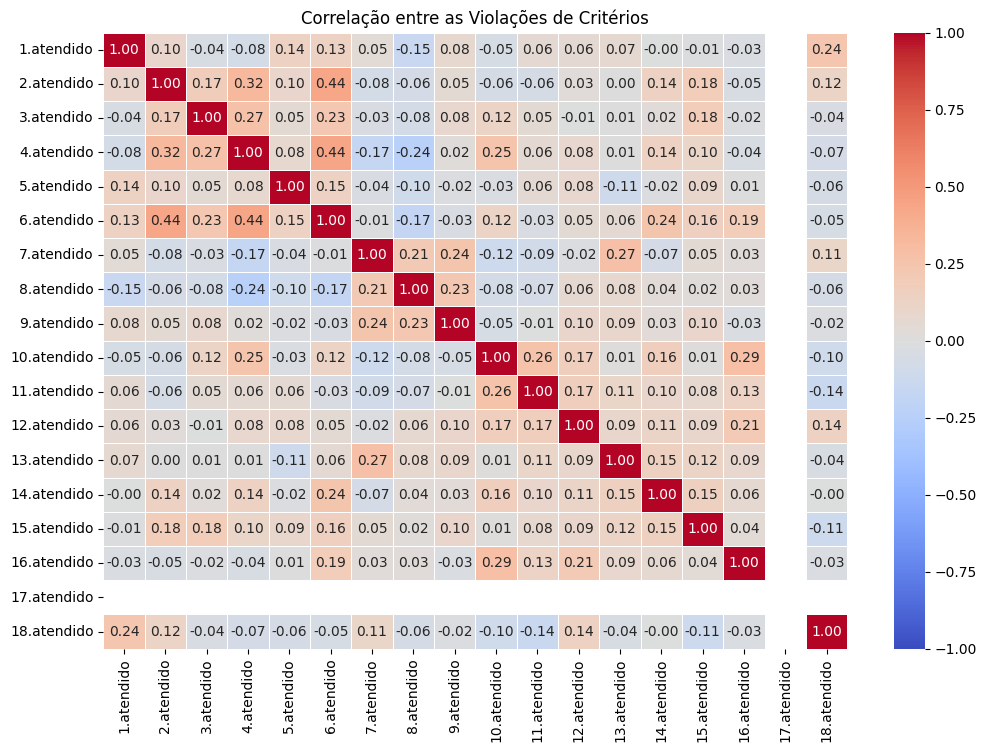

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.heatmap(matriz_correlacao,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1, vmax=1,
            linewidths=.5)

plt.title("Correlação entre as Violações de Critérios")
plt.show()

In [ ]:
df_falhas = questions_expanded.copy()

colunas_atendido = [col for col in df_falhas.columns if col.endswith('.atendido')]

df_falhas = (~df_falhas[colunas_atendido]).astype(int)

df_falhas

,1.atendido,2.atendido,3.atendido,4.atendido,5.atendido,6.atendido,7.atendido,8.atendido,9.atendido,10.atendido,11.atendido,12.atendido,13.atendido,14.atendido,15.atendido,16.atendido,17.atendido,18.atendido
0,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0
1,0,0,0,0,0,0,1,1,0,0,0,0,1,1,0,0,0,0
2,0,0,0,0,1,1,1,1,0,0,0,0,1,1,0,0,0,0
3,0,0,1,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,1,1,1,1,0,0,0,0,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
235,0,0,0,0,1,0,1,1,1,0,0,0,1,0,1,0,0,0
236,0,0,0,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0
237,0,0,0,0,1,0,1,0,0,0,1,0,1,1,0,0,0,0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


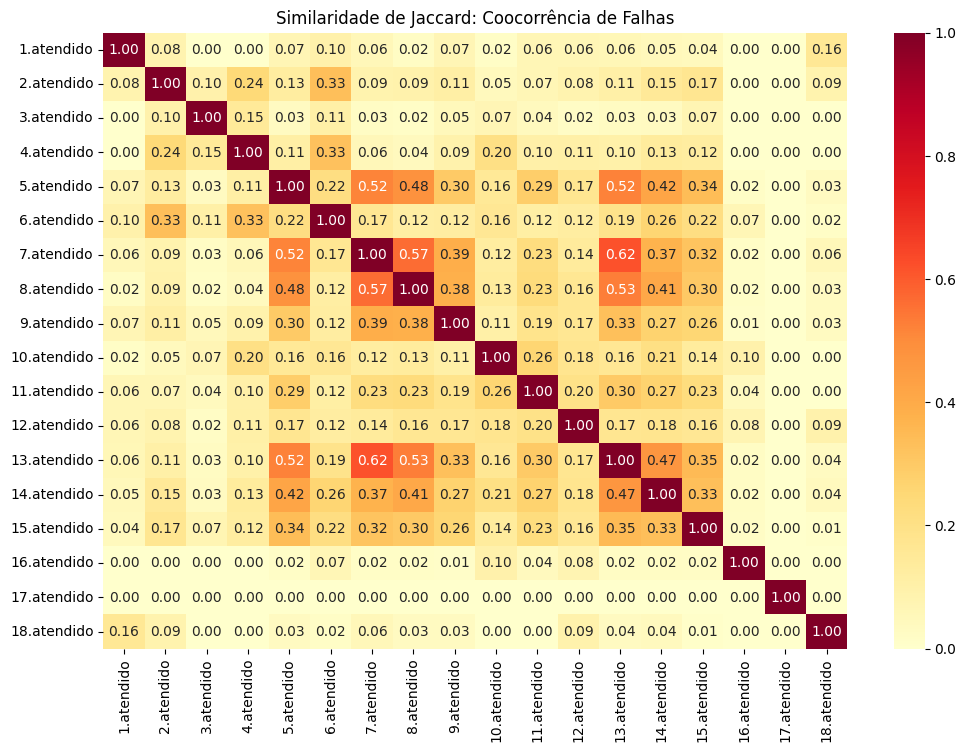

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

jaccard_sim = 1 - pairwise_distances(df_falhas.T.values, metric="jaccard")

df_jaccard = pd.DataFrame(jaccard_sim, index=df_falhas.columns, columns=df_falhas.columns)

plt.figure(figsize=(12, 8))
sns.heatmap(df_jaccard, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Similaridade de Jaccard: Coocorrência de Falhas")
plt.show()